In [39]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pybedtools
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, wilcoxon
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial

# define region of interest
region_start = 7000000
region_end = 22000000
chrom = 'chr17'
gene = 'TP53-upstream'

In [ ]:
# load files
included_samples = pd.read_csv('../../../SV_sample_data/data/final_analysis_samples.csv') # unique patient samples
print("Total number of samples: ", len(included_samples))

clustering_regions = pd.read_csv('../../Clustered_SVs/results/merged_clustered_sv_events.csv')
clustering_regions = clustering_regions[clustering_regions['sample'].isin(included_samples['tumor_normal_pair'])]

sv_data = pd.read_csv('../../Clustered_SVs/results/all_samples_annotated_bedpe.txt', sep='\t') # chrom1	(int); start1; end1; chrom2; start2; end2; sample
sv_data = sv_data[sv_data['sample'].isin(included_samples['tumor_normal_pair'])]

tad_boundaries = pd.read_csv('../../../SRB_analysis/data/hg38_ref_files/final_noncoding_annotation_file_list_combined_7_18_23.txt', sep='\t')
tad_boundaries = tad_boundaries[tad_boundaries['annotation'] == 'ewing_and_osteosarcoma_tad_boundary']
tad_boundaries = tad_boundaries.sort_values(['chrom', 'start']).reset_index(drop=True)

def load_and_process_gaps(gap_file):
    gaps = pd.read_csv(gap_file, sep='\t', 
                      names=['chrom', 'start', 'end', 'part_num', 'component_type', 
                            'component_id', 'gap_type_or_start', 'linkage_or_end', 'orientation_or_evidence'])
    # filter for gap regions
    gaps = gaps[gaps['component_type'] == 'N'] # column 5 is the component type (N = gap)
    # convert from 1-based to 0-based coordinates by subtracting 1 from start (end remains the same as it's exclusive in 0-based)
    gaps['start'] = gaps['start'] - 1
    
    return gaps[['chrom', 'start', 'end']]

blacklist = pd.read_csv("../../../SRB_analysis/data/hg38_ref_files/ENCFF356LFX.bed.gz", sep='\t', names=['chrom', 'start', 'end'], compression='gzip')
gap = load_and_process_gaps("../../../SRB_analysis/data/hg38_ref_files/hg38.agp.gz")

Total number of samples:  207


In [41]:
# Find samples with the clustered SV region of interest
def find_samples_with_clustered_region(clustered_file, start, end, chrom):
    
    samples_clustered = []
    clustered_file = clustered_file.copy()
    clustered_file['chr'] = 'chr' + clustered_file['chr'].astype(str)
    
    samples = clustered_file['sample'].unique()

    for sample in samples:
        sample_data = clustered_file[clustered_file['sample'] == sample]
        overlap = (sample_data['chr'] == chrom) & ~((sample_data['end'] < start) | (sample_data['start'] > end))
        if overlap.any():
            samples_clustered.append(sample)

    return samples_clustered

# Construct TADs from consecutive boundaries (span is end of one boundary to start of next boundary)
def construct_tads_from_boundaries(tad_boundaries, blacklist, gap):

    tads = []
    
    for chrom in tad_boundaries['chrom'].unique():
        chrom_boundaries = tad_boundaries[tad_boundaries['chrom'] == chrom].sort_values('start').reset_index(drop=True)
        
        # Each TAD is defined by consecutive boundaries
        for i in range(len(chrom_boundaries) - 1):
            tad_start = chrom_boundaries.loc[i, 'end']  # End of current boundary
            tad_end = chrom_boundaries.loc[i + 1, 'start']  # Start of next boundary
            
            # Store both the TAD region and the boundary regions
            tads.append({
                'chrom': chrom,
                'tad_start': tad_start,
                'tad_end': tad_end,
                'boundary1_start': chrom_boundaries.loc[i, 'start'],
                'boundary1_end': chrom_boundaries.loc[i, 'end'],
                'boundary2_start': chrom_boundaries.loc[i + 1, 'start'],
                'boundary2_end': chrom_boundaries.loc[i + 1, 'end']
            })

    tads_df = pd.DataFrame(tads)
        
    # Combine blacklist + gap regions
    exclude_df = pd.concat([blacklist[['chrom', 'start', 'end']], gap[['chrom', 'start', 'end']]], ignore_index=True).dropna()
    # Build BedTool objects
    tads_bed = pybedtools.BedTool.from_dataframe(
        tads_df[['chrom', 'tad_start', 'tad_end']].rename(
            columns={'tad_start': 'start', 'tad_end': 'end'}
        )
    )
    exclude_bed = pybedtools.BedTool.from_dataframe(exclude_df[['chrom', 'start', 'end']])
    overlaps = tads_bed.intersect(exclude_bed, u=True) # returns overlapping TAD intervals
    overlap_df = overlaps.to_dataframe(names=['chrom', 'start', 'end'])
    # Mark overlap flag on TAD table
    overlap_keys = set(
        zip(overlap_df['chrom'].astype(str),
            overlap_df['start'].astype(int),
            overlap_df['end'].astype(int))
    )
    tads_df['overlaps_blacklist_or_gap'] = tads_df.apply(
        lambda r: (str(r['chrom']), int(r['tad_start']), int(r['tad_end'])) in overlap_keys,
        axis=1
    )

    n_total = len(tads_df)
    n_overlap = int(tads_df['overlaps_blacklist_or_gap'].sum())
    n_kept = n_total - n_overlap
    print(f"Total TADs created from boundaries: {n_total}")
    print(f"TADs overlapping blacklist/gap: {n_overlap}")
    print(f"TADs kept: {n_kept}")
    if n_overlap > 0:
        tads_df = tads_df[~tads_df['overlaps_blacklist_or_gap']].copy()

    return tads_df


# Check if SV spans entire boundary
def spans_entire_boundary(sv_start, sv_end, boundary_start, boundary_end):
    return (sv_start <= boundary_start) and (sv_end >= boundary_end)

# Check if SV is boundary-altering (spans entire boundary on either flank)
def is_boundary_altering_sv(sv_row, tad_info):
    
    # Get SV span on the chromosome
    sv_start = min(sv_row['start1'], sv_row['start2'])
    sv_end = max(sv_row['start1'], sv_row['start2'])
    
    # Check if SV spans entire boundary 1 (left flank)
    spans_boundary1 = spans_entire_boundary(
        sv_start, sv_end, 
        tad_info['boundary1_start'], 
        tad_info['boundary1_end']
    )
    
    # Check if SV spans entire boundary 2 (right flank)
    spans_boundary2 = spans_entire_boundary(
        sv_start, sv_end,
        tad_info['boundary2_start'],
        tad_info['boundary2_end']
    )
    
    return spans_boundary1 or spans_boundary2

# Calculate % BA-SVs for each TAD in each sample
def calculate_ba_sv_percentage_per_tad(sample, sv_data, tads_df):

    sample_svs = sv_data[sv_data['sample'] == sample].copy()
    sample_svs['chrom1'] = 'chr' + sample_svs['chrom1'].astype(str)
    sample_svs['chrom2'] = 'chr' + sample_svs['chrom2'].astype(str)
    
    results = []
    
    for idx, tad in tads_df.iterrows():
        tad_chrom = tad['chrom']
        tad_start = tad['tad_start']
        tad_end = tad['tad_end']
        
        # Find all SVs with a breakpoint within this TAD (inclusive of boundaries - boundary1_start to boundary2_end)
        extended_start = tad['boundary1_start']
        extended_end = tad['boundary2_end']
        
        tad_svs = sample_svs[
            ((sample_svs['chrom1'] == tad_chrom) & 
             (sample_svs['start1'] >= extended_start) & 
             (sample_svs['start1'] <= extended_end)) |
            ((sample_svs['chrom2'] == tad_chrom) & 
             (sample_svs['start2'] >= extended_start) & 
             (sample_svs['start2'] <= extended_end))
        ]
        
        # Filter to SVs < 2Mb
        tad_svs = tad_svs[
            (tad_svs['chrom1'] == tad_svs['chrom2']) &
            (abs(tad_svs['start2'] - tad_svs['start1']) < 2000000)
        ]
        total_svs = len(tad_svs)
        
        if total_svs == 0:
            ba_sv_percentage = np.nan
            ba_sv_count = 0
        else:
            # Count boundary-altering SVs
            ba_sv_count = sum(tad_svs.apply(lambda row: is_boundary_altering_sv(row, tad), axis=1))
            ba_sv_percentage = (ba_sv_count / total_svs) * 100
        
        # Check if TAD is in clustering region
        in_clustering_region = (tad_chrom == chrom) and not (tad_start > region_end or tad_end < region_start)
        
        results.append({
            'sample': sample,
            'tad_chr': tad_chrom,
            'tad_start': tad_start,
            'tad_end': tad_end,
            'boundary1_start': tad['boundary1_start'],
            'boundary1_end': tad['boundary1_end'],
            'boundary2_start': tad['boundary2_start'],
            'boundary2_end': tad['boundary2_end'],
            'total_svs': total_svs,
            'ba_sv_count': ba_sv_count,
            'ba_sv_percentage': ba_sv_percentage,
            'in_clustering_region': in_clustering_region
        })
    
    return pd.DataFrame(results)


# 1. Construct TADs from boundaries, exclude TADs in ENCODE blacklisted or gap regions
tads_df = construct_tads_from_boundaries(tad_boundaries, blacklist, gap)

# 2. Find samples with clustering
samples_with_clustering = find_samples_with_clustered_region(clustering_regions, region_start, region_end, chrom)
print(f"\nFound {len(samples_with_clustering)} samples with {gene} clustering region")

# 3. Calculate BA-SV percentages for all samples with clustered SV of interest
all_results = []
for sample in samples_with_clustering:
    print(f"Processing sample: {sample}")
    sample_results = calculate_ba_sv_percentage_per_tad(sample, sv_data, tads_df)
    all_results.append(sample_results)

clustered_results = pd.concat(all_results, ignore_index=True)

# 4. Compare TADs in clusering region vs outside clustering region (filter out TADs with no SVs for statistical testing)
clustered_results_filtered = clustered_results[clustered_results['total_svs'] > 0]
clustering_region_tads = clustered_results_filtered[clustered_results_filtered['in_clustering_region'] == True]['ba_sv_percentage'].dropna()
non_clustering_region_tads = clustered_results_filtered[clustered_results_filtered['in_clustering_region'] == False]['ba_sv_percentage'].dropna()

print(f"\nTADs in {gene} region: n={len(clustering_region_tads)}, mean BA-SV%={clustering_region_tads.mean():.2f}")
print(f"TADs outside {gene} region: n={len(non_clustering_region_tads)}, mean BA-SV%={non_clustering_region_tads.mean():.2f}")
clustered_results.to_csv(f'../results/{gene}_clustered_samples_ba_sv_results.csv', index=False)

Total TADs created from boundaries: 8835
TADs overlapping blacklist/gap: 449
TADs kept: 8386

Found 51 samples with TP53-upstream clustering region
Processing sample: 24T02-24N02
Processing sample: 39T01-39N01
Processing sample: CCG1106_005_T1-CCG1106_005_WB
Processing sample: CCG1106_075_T1-CCG1106_075_WB
Processing sample: CCG1106_086_T1-CCG1106_086_WB
Processing sample: SA541886-SA541887
Processing sample: SA541892-SA541893
Processing sample: SA541894-SA541895
Processing sample: SA541906-SA541907
Processing sample: SA541934-SA541935
Processing sample: SA541936-SA541937
Processing sample: SA541940-SA541941
Processing sample: SAMN03223756-SAMN03223799
Processing sample: SAMN03223803-SAMN03223740
Processing sample: SJOS001101_M7-SJOS001101_G1
Processing sample: SJOS001107_D1-SJOS001107_G1
Processing sample: SJOS001108_M1-SJOS001108_G1
Processing sample: SJOS001117_D1-SJOS001117_G1
Processing sample: SJOS001119_D1-SJOS001119_G1
Processing sample: SJOS001121_D2-SJOS001121_G1
Processing s

Region effect: β=1.2033, p=1.5364e-10


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_75589/2380854858.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([f'{gene}\nregion', f'Non-{gene}\nregion'], fontsize=14)


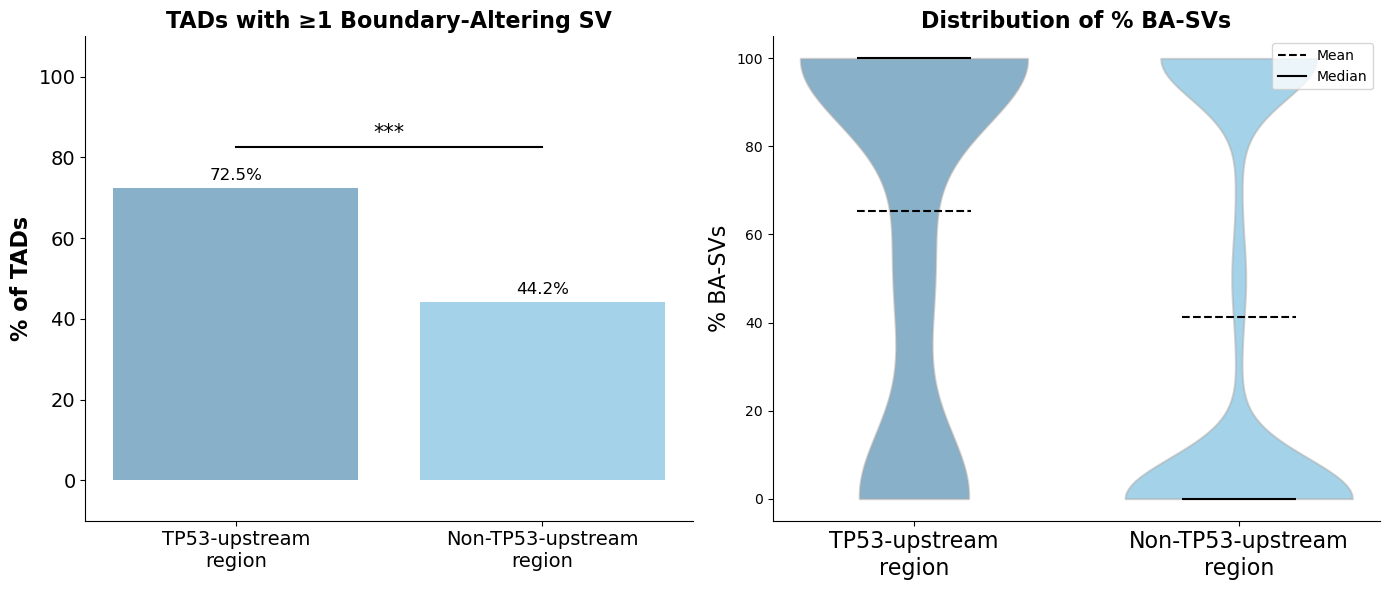

In [42]:
df_model = clustered_results_filtered.copy()
df_model['has_ba'] = (df_model['ba_sv_percentage'] > 0).astype(int)
df_model['region'] = df_model['in_clustering_region'].astype(int)

# GEE 
model = GEE.from_formula(
    "has_ba ~ region",
    groups="sample",
    data=df_model,
    family=Binomial()
).fit()
gee_p = model.pvalues['region']
gee_beta = model.params['region']
gee_ci_low, gee_ci_high = model.conf_int().loc['region']
print(f"Region effect: β={gee_beta:.4f}, p={gee_p:.4e}")

# Descriptive stats
clustered_tads = clustered_results_filtered[clustered_results_filtered['in_clustering_region'] == True]
non_clustered_tads = clustered_results_filtered[clustered_results_filtered['in_clustering_region'] == False]

clustered_prop = (clustered_tads['ba_sv_percentage'] > 0).mean() * 100
non_clustered_prop = (non_clustered_tads['ba_sv_percentage'] > 0).mean() * 100
clustered_has_ba = (clustered_tads['ba_sv_percentage'] > 0).sum()
non_clustered_has_ba = (non_clustered_tads['ba_sv_percentage'] > 0).sum()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#136394', '#4BA8D5']

# Panel 1: Proportion bar (annotated with LMM p-value)
ax1 = axes[0]
bars = ax1.bar(
    [f'{gene}\nregion', f'Non-{gene}\nregion'],
    [clustered_prop, non_clustered_prop],
    color=colors, alpha=0.5
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('% of TADs', fontsize=16, fontweight='bold')
ax1.set_title('TADs with ≥1 Boundary-Altering SV', fontsize=16, fontweight='bold')
ax1.set_xticklabels([f'{gene}\nregion', f'Non-{gene}\nregion'], fontsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_ylim([-10, 110])

for i, (bar, v) in enumerate(zip(bars, [clustered_prop, non_clustered_prop])):
    ax1.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12)

y_max = max(clustered_prop, non_clustered_prop) + 10
ax1.plot([0, 1], [y_max, y_max], 'k-', linewidth=1.5)
sig_text = '***' if gee_p < 0.001 else '**' if gee_p < 0.01 else '*' if gee_p < 0.05 else 'ns'
ax1.text(0.5, y_max + 2, sig_text, ha='center', fontsize=15)

# Panel 2: Violin — annotate with GLMM OR
ax2 = axes[1]
parts = ax2.violinplot(
    [clustered_tads['ba_sv_percentage'], non_clustered_tads['ba_sv_percentage']],
    positions=[0, 1], showmeans=True, showmedians=True, showextrema=False, widths=0.7
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('darkgray')
    pc.set_linewidth(1.5)
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(1.5)
parts['cmeans'].set_linestyle('--')
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

ax2.set_xticks([0, 1])
ax2.set_xticklabels([f'{gene}\nregion', f'Non-{gene}\nregion'], fontsize=16)
ax2.set_ylabel('% BA-SVs', fontsize=16)
ax2.set_title('Distribution of % BA-SVs', fontsize=16, fontweight='bold')

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, label='Mean'),
    Line2D([0], [0], color='black', linewidth=1.5, label='Median')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'../results/{gene}_clustered_samples_ba_sv_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [73]:
# Analyze samples clustered SV of interest
print(f"ANALYZING SAMPLES WITHOUT {gene} CLUSTERING")

# Find samples WITHOUT clustering region
all_samples = sv_data['sample'].unique()
samples_without_clustering = [s for s in all_samples if s not in samples_with_clustering]

print(f"\nTotal samples in dataset: {len(all_samples)}")
print(f"Samples WITH {gene} clustering: {len(samples_with_clustering)}")
print(f"Samples WITHOUT {gene} clustering: {len(samples_without_clustering)}")

# Calculate BA-SV percentages for all samples WITHOUT clustering
all_results_no_cluster = []
for sample in samples_without_clustering:
    print(f"  Processing sample: {sample}")
    sample_results = calculate_ba_sv_percentage_per_tad(sample, sv_data, tads_df)
    all_results_no_cluster.append(sample_results)

no_cluster_results = pd.concat(all_results_no_cluster, ignore_index=True)
no_cluster_results_filtered = no_cluster_results[no_cluster_results['total_svs'] > 0] # Filter out TADs with no SVs

# Separate by region
no_cluster_gene_region = no_cluster_results_filtered[no_cluster_results_filtered['in_clustering_region'] == True]
no_cluster_non_gene_region = no_cluster_results_filtered[no_cluster_results_filtered['in_clustering_region'] == False]

no_cluster_results_filtered.to_csv(f'../results/{gene}_non_clustered_samples_ba_sv_results.csv', index=False)

ANALYZING SAMPLES WITHOUT TP53-upstream CLUSTERING

Total samples in dataset: 205
Samples WITH TP53-upstream clustering: 51
Samples WITHOUT TP53-upstream clustering: 154
  Processing sample: 09T02-09N01
  Processing sample: 10T03-10N02
  Processing sample: 13T02-13N02
  Processing sample: 17_439_00067_T2-17_439_00067_WB
  Processing sample: 17_439_00097_T1-17_439_00097_WB
  Processing sample: 21T01-21N01
  Processing sample: 41T03-41N03
  Processing sample: CCG1106_074_T1-CCG1106_074_WB
  Processing sample: CCG1106_083_T1-CCG1106_083_WB
  Processing sample: CCG1106_084_T1-CCG1106_084_WB
  Processing sample: SA541864-SA541865
  Processing sample: SA541866-SA541867
  Processing sample: SA541868-SA541869
  Processing sample: SA541870-SA541871
  Processing sample: SA541872-SA541873
  Processing sample: SA541874-SA541875
  Processing sample: SA541876-SA541877
  Processing sample: SA541878-SA541879
  Processing sample: SA541880-SA541881
  Processing sample: SA541882-SA541883
  Processing sam

In [43]:
# GEE on samples WITHOUT {gene} clustering — control arm
# Same question as the clustered analysis: is there BA-SV enrichment in the gene region vs elsewhere?

no_cluster_results_filtered = pd.read_csv(f'../results/{gene}_non_clustered_samples_ba_sv_results.csv')
no_cluster_gene_region = no_cluster_results_filtered[no_cluster_results_filtered['in_clustering_region'] == True]
no_cluster_non_gene_region = no_cluster_results_filtered[no_cluster_results_filtered['in_clustering_region'] == False]

df_model_nc = no_cluster_results_filtered.copy()
df_model_nc['has_ba'] = (df_model_nc['ba_sv_percentage'] > 0).astype(int)
df_model_nc['region'] = df_model_nc['in_clustering_region'].astype(int)

n_samples_nc  = df_model_nc['sample'].nunique()
n_region_tads = int((df_model_nc['region'] == 1).sum())

nc_gee_p = nc_gee_beta = nc_gee_ci_low = nc_gee_ci_high = np.nan
if n_samples_nc >= 3 and n_region_tads >= 5 and df_model_nc['has_ba'].nunique() > 1:
    try:
        model_nc = GEE.from_formula(
            "has_ba ~ region",
            groups="sample",
            data=df_model_nc,
            family=Binomial()
        ).fit()
        nc_gee_beta = model_nc.params['region']
        nc_gee_p    = model_nc.pvalues['region']
        nc_gee_ci_low, nc_gee_ci_high = model_nc.conf_int().loc['region']
        print(f"Region effect (non-clustered samples): β={nc_gee_beta:.4f}, p={nc_gee_p:.4e}")
    except Exception as e:
        print(f"GEE did not fit: {e}")
else:
    print(f"Insufficient data for GEE (samples={n_samples_nc}, region TADs={n_region_tads})")

# Descriptive stats
nc_gene_prop     = (no_cluster_gene_region['ba_sv_percentage'] > 0).mean() * 100 if len(no_cluster_gene_region) else 0
nc_non_gene_prop = (no_cluster_non_gene_region['ba_sv_percentage'] > 0).mean() * 100 if len(no_cluster_non_gene_region) else 0

print(f"{gene} region:     {nc_gene_prop:.1f}% of TADs have ≥1 BA-SV (n={len(no_cluster_gene_region)})")
print(f"Non-{gene} region: {nc_non_gene_prop:.1f}% of TADs have ≥1 BA-SV (n={len(no_cluster_non_gene_region)})")

# Compare clustered SV-region TADs from clustered vs non-clustered samples. 
# Fixed effect = clustering status; sample = group (random via GEE).

clustered_region_bg = clustered_tads.copy()
clustered_region_bg['has_ba'] = (clustered_region_bg['ba_sv_percentage'] > 0).astype(int)
clustered_region_bg['clustered_sample'] = 1

nonclustered_region_bg = no_cluster_gene_region.copy()
nonclustered_region_bg['has_ba'] = (nonclustered_region_bg['ba_sv_percentage'] > 0).astype(int)
nonclustered_region_bg['clustered_sample'] = 0

df_between = pd.concat([clustered_region_bg, nonclustered_region_bg], ignore_index=True)

n_samples_bg = df_between['sample'].nunique()
n_nc_region  = int((df_between['clustered_sample'] == 0).sum())

comp_gee_p = comp_gee_beta = comp_gee_ci_low = comp_gee_ci_high = np.nan
if n_samples_bg >= 5 and n_nc_region >= 5 and df_between['has_ba'].nunique() > 1:
    try:
        model_bg = GEE.from_formula(
            "has_ba ~ clustered_sample",
            groups="sample",
            data=df_between,
            family=Binomial()
        ).fit()
        comp_gee_beta = model_bg.params['clustered_sample']
        comp_gee_p    = model_bg.pvalues['clustered_sample']
        comp_gee_ci_low, comp_gee_ci_high = model_bg.conf_int().loc['clustered_sample']
        print(f"\nBetween-group (clustering) effect: β={comp_gee_beta:.4f}, p={comp_gee_p:.4e}")
    except Exception as e:
        print(f"\nGEE did not fit: {e}")
else:
    print(f"\nInsufficient data for between-group GEE "
          f"(samples={n_samples_bg}, non-clustered region TADs={n_nc_region})")

clustered_gene_prop_bg    = (clustered_region_bg['ba_sv_percentage'] > 0).mean() * 100 if len(clustered_region_bg) else 0
nonclustered_gene_prop_bg = (nonclustered_region_bg['ba_sv_percentage'] > 0).mean() * 100 if len(nonclustered_region_bg) else 0
print(f"Clustered samples {gene}-region:     {clustered_gene_prop_bg:.1f}% "
      f"({df_between[df_between.clustered_sample==1]['sample'].nunique()} samples)")
print(f"Non-clustered samples {gene}-region: {nonclustered_gene_prop_bg:.1f}% "
      f"({df_between[df_between.clustered_sample==0]['sample'].nunique()} samples)")

Region effect (non-clustered samples): β=0.2059, p=3.9615e-01
TP53-upstream region:     60.0% of TADs have ≥1 BA-SV (n=110)
Non-TP53-upstream region: 55.0% of TADs have ≥1 BA-SV (n=9008)

Between-group (clustering) effect: β=0.5639, p=1.1455e-01
Clustered samples TP53-upstream-region:     72.5% (46 samples)
Non-clustered samples TP53-upstream-region: 60.0% (51 samples)


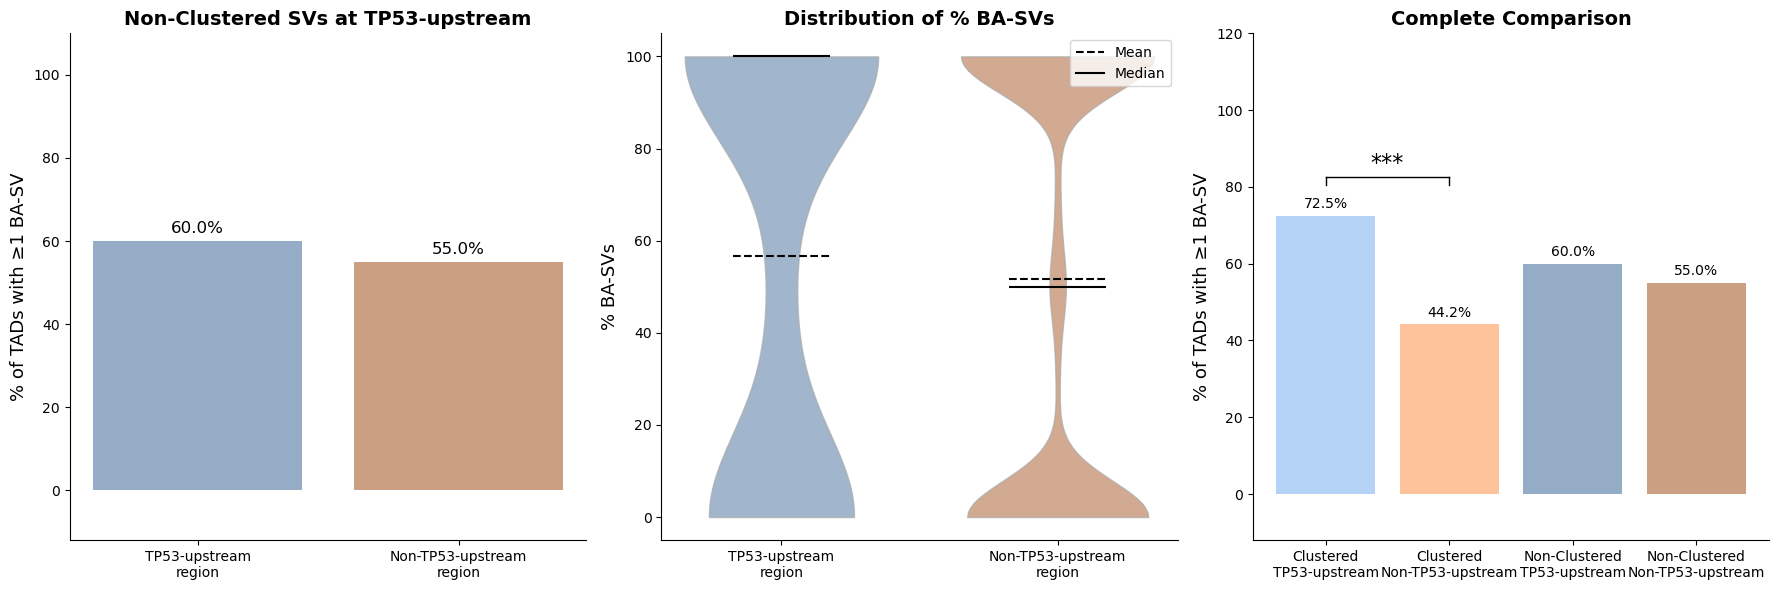

In [ ]:
lmm_p   = gee_p          # clustered-samples region effect (primary)
p_nc    = nc_gee_p       # non-clustered-samples region effect (Analysis 1)
p_comp  = comp_gee_p     # between-group / clustering effect (Analysis 2)

non_clustered_svs_gene_prop     = nc_gene_prop
non_clustered_svs_non_gene_prop = nc_non_gene_prop
nonclustered_svs_clustered_region     = no_cluster_gene_region
nonclustered_svs_non_clustered_region = no_cluster_non_gene_region

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pastel_colors = sns.color_palette("pastel")
color_gene_clustered = pastel_colors[0]
color_nongene_clustered = pastel_colors[1]

def darken_color(color, factor=0.75):
    hsv = mcolors.rgb_to_hsv(color)
    hsv[2] *= factor
    return mcolors.hsv_to_rgb(hsv)

color_gene_nonclustered = darken_color(color_gene_clustered)
color_nongene_nonclustered = darken_color(color_nongene_clustered)

# Panel 1: Non-clustered samples - Bar plot
ax1 = axes[0]

regions = [f'{gene}\nregion', f'Non-{gene}\nregion']
proportions = [non_clustered_svs_gene_prop, non_clustered_svs_non_gene_prop]
colors = [color_gene_nonclustered, color_nongene_nonclustered]

bars = ax1.bar(regions, proportions, color=colors, alpha=0.8, edgecolor='none')
ax1.set_ylabel('% of TADs with ≥1 BA-SV', fontsize=13)
ax1.set_title(f'Non-Clustered SVs at {gene}', fontsize=14, fontweight='bold')
ax1.set_ylim([-12, 110])

for i, (bar, v) in enumerate(zip(bars, proportions)):
    ax1.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

if p_nc is not None and p_nc < 0.05:
    y_bracket = max(proportions) + 10
    ax1.plot([0, 1], [y_bracket, y_bracket], 'k-', linewidth=1)
    ax1.plot([0, 0], [y_bracket-2, y_bracket], 'k-', linewidth=1)
    ax1.plot([1, 1], [y_bracket-2, y_bracket], 'k-', linewidth=1)
    sig_text = '***' if p_nc < 0.001 else '**' if p_nc < 0.01 else '*'
    ax1.text(0.5, y_bracket + 2, sig_text, ha='center', fontsize=16)

# Panel 2: Non-clustered samples - Violin plot
ax2 = axes[1]

if len(nonclustered_svs_clustered_region) > 5 and len(nonclustered_svs_non_clustered_region) > 5:
    parts = ax2.violinplot(
        [nonclustered_svs_clustered_region['ba_sv_percentage'],
         nonclustered_svs_non_clustered_region['ba_sv_percentage']],
        positions=[0, 1], showmeans=True, showmedians=True,
        showextrema=False, widths=0.7
    )

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor([color_gene_nonclustered, color_nongene_nonclustered][i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('darkgray')
        pc.set_linewidth(1)

    parts['cmeans'].set_color('black')
    parts['cmeans'].set_linewidth(1.5)
    parts['cmeans'].set_linestyle('--')
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    ax2.set_xticks([0, 1])
    ax2.set_xticklabels([f'{gene}\nregion', f'Non-{gene}\nregion'], fontsize=10)
    ax2.set_ylabel('% BA-SVs', fontsize=13)
    ax2.set_title('Distribution of % BA-SVs', fontsize=14, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    legend_elements = [
        Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Mean'),
        Line2D([0], [0], color='black', linewidth=1.5, label='Median')
    ]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)
else:
    ax2.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12)

# Panel 3: 4-bar comparison with significance brackets
ax3 = axes[2]

x_pos = np.arange(4)
groups = [
    f'Clustered\n{gene}', f'Clustered\nNon-{gene}',
    f'Non-Clustered\n{gene}', f'Non-Clustered\nNon-{gene}'
]
values = [clustered_prop, non_clustered_prop,
          non_clustered_svs_gene_prop, non_clustered_svs_non_gene_prop]
colors_all = [color_gene_clustered, color_nongene_clustered,
              color_gene_nonclustered, color_nongene_nonclustered]

bars = ax3.bar(x_pos, values, color=colors_all, alpha=0.8, edgecolor='none')
ax3.set_ylabel('% of TADs with ≥1 BA-SV', fontsize=13)
ax3.set_title('Complete Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, fontsize=10)
ax3.set_ylim([-12, 120])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for i, (bar, v) in enumerate(zip(bars, values)):
    ax3.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10)

# Bracket 1: Clustered gene-region vs Non-clustered gene-region (Analysis 2)
if p_comp is not None and p_comp < 0.05:
    y1 = max(values[0], values[2]) + 20
    ax3.plot([0, 2], [y1, y1], 'k-', linewidth=1)
    ax3.plot([0, 0], [y1-2, y1], 'k-', linewidth=1)
    ax3.plot([2, 2], [y1-2, y1], 'k-', linewidth=1)
    sig_text1 = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*'
    ax3.text(1, y1 + 2, sig_text1, ha='center', fontsize=16)

# Bracket 2: Clustered gene-region vs Clustered non-gene-region (primary)
if lmm_p is not None and lmm_p < 0.05:
    y2 = max(values[0], values[1]) + 10
    ax3.plot([0, 1], [y2, y2], 'k-', linewidth=1)
    ax3.plot([0, 0], [y2-2, y2], 'k-', linewidth=1)
    ax3.plot([1, 1], [y2-2, y2], 'k-', linewidth=1)
    sig_text2 = '***' if lmm_p < 0.001 else '**' if lmm_p < 0.01 else '*'
    ax3.text(0.5, y2 + 2, sig_text2, ha='center', fontsize=16)

# Bracket 3: Non-clustered gene-region vs Non-clustered non-gene-region (Analysis 1)
if p_nc is not None and p_nc < 0.05:
    y3 = max(values[2], values[3]) + 10
    ax3.plot([2, 3], [y3, y3], 'k-', linewidth=1)
    ax3.plot([2, 2], [y3-2, y3], 'k-', linewidth=1)
    ax3.plot([3, 3], [y3-2, y3], 'k-', linewidth=1)
    sig_text3 = '***' if p_nc < 0.001 else '**' if p_nc < 0.01 else '*'
    ax3.text(2.5, y3 + 2, sig_text3, ha='center', fontsize=16)

plt.tight_layout()
plt.savefig(f'../results/{gene}_non_clustered_samples_ba_sv_results.png', dpi=300, bbox_inches='tight')
plt.show()